# Fixed Pipeline: RoBERTa + BlenderBot + Groq
**Fixes from previous version:**
- RoBERTa emotion detector now wired into full_pipeline()
- Groq meta-commentary stripped from responses
- Evaluation metrics added (keyword score, ROUGE-L, false positive rate)
- False positive detection with 5 check types

In [1]:
# ── CELL A: Install RoBERTa dependency (run once) ─────────────────────
!pip install rouge-score -q
print('Done')

  Preparing metadata (setup.py) ... done
Done


In [1]:
# ── CELL B: RoBERTa Emotion Detector ──────────────────────────────────
# This is the SAME emotion_detector.py you already have locally
# Adding it directly here so the Colab notebook is self-contained

from transformers import pipeline as hf_pipeline
import warnings
warnings.filterwarnings('ignore')

EMOTION_MAP = {
    'admiration':'happy','amusement':'happy','approval':'happy',
    'excitement':'happy','gratitude':'happy','joy':'happy',
    'love':'happy','optimism':'happy','pride':'happy','relief':'happy',
    'disappointment':'sad','grief':'sad','remorse':'sad','sadness':'sad',
    'anger':'angry','annoyance':'angry','disapproval':'angry','disgust':'angry',
    'embarrassment':'fear','fear':'fear','nervousness':'fear',
    'confusion':'stressed','desire':'stressed',
    'curiosity':'surprised','realization':'surprised','surprise':'surprised',
    'neutral':'neutral',
}

def get_intensity(score):
    if score >= 0.80: return 'high'
    elif score >= 0.50: return 'medium'
    else: return 'low'

print('Loading RoBERTa emotion detector...')
roberta_classifier = hf_pipeline(
    task='text-classification',
    model='SamLowe/roberta-base-go_emotions',
    top_k=None,
    device=0 if __import__('torch').cuda.is_available() else -1,
    framework='pt'
)
print('RoBERTa loaded.')

def detect_emotion(text):
    """Returns dict: top_emotion, confidence, intensity, raw_label"""
    if not text or not text.strip():
        return {'top_emotion':'neutral','confidence':1.0,'intensity':'low','raw_label':'neutral'}

    outputs = roberta_classifier([text])[0]
    outputs_sorted = sorted(outputs, key=lambda x: x['score'], reverse=True)

    best_raw   = outputs_sorted[0]['label']
    best_score = outputs_sorted[0]['score']

    return {
        'top_emotion': EMOTION_MAP.get(best_raw, 'neutral'),
        'confidence':  round(best_score, 4),
        'intensity':   get_intensity(best_score),
        'raw_label':   best_raw,
    }

# Quick sanity check
test = detect_emotion('I have five deadlines and I have no idea where to start')
print(f'Sanity check → emotion: {test["top_emotion"]} ({test["raw_label"]}) | intensity: {test["intensity"]}')

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Loading RoBERTa emotion detector...
RoBERTa loaded.
Sanity check → emotion: stressed (confusion) | intensity: high


In [ ]:
# # ── CELL C: Updated full_pipeline() — RoBERTa now wired in ────────────
# import re

# def clean_groq_output(text):
#     """Remove meta-commentary Groq sometimes adds before/after the response."""
#     # Remove preambles like "Here's a revised response:"
#     text = re.sub(
#         r'^(here[\s\S]{0,20}response[\s\S]{0,10}:\s*)',
#         '', text, flags=re.IGNORECASE
#     ).strip()
#     # Remove explanations after the response
#     for cut in ['\n\nThis response', '\n\nNote:', '\n\nThe response', '\n\nI chose']:
#         if cut in text:
#             text = text.split(cut)[0].strip()
#     # Remove surrounding quotes
#     if text.startswith('"') and text.endswith('"'):
#         text = text[1:-1].strip()
#     return text


# def full_pipeline(user_input, persona='friend'):
#     """
#     FIXED: emotion is now detected by RoBERTa automatically.
#     No more manual emotion labels.

#     Flow:
#       user_input
#         → RoBERTa → emotion, intensity, confidence, raw_label
#         → BlenderBot(emotion, style, user_input) → base_response
#         → Groq(base_response + emotion + intensity + survey_rules + persona) → final
#     """

#     # ── STEP 1: RoBERTa detects emotion ───────────────────────────────
#     emo_result  = detect_emotion(user_input)
#     emotion     = emo_result['top_emotion']
#     intensity   = emo_result['intensity']
#     confidence  = emo_result['confidence']
#     raw_label   = emo_result['raw_label']

#     # ── STEP 2: Get survey rules + style ──────────────────────────────
#     rules    = SURVEY_RULES.get(emotion, SURVEY_RULES['neutral'])
#     int_rule = INTENSITY_RULES.get(intensity, INTENSITY_RULES['medium'])
#     per_rule = PERSONA_INSTRUCTIONS.get(persona, PERSONA_INSTRUCTIONS['friend'])
#     style    = EMOTION_STYLE.get(emotion, 'supportive')

#     # ── STEP 3: BlenderBot base response ──────────────────────────────
#     base = blenderbot_respond(emotion, style, user_input)

#     # ── STEP 4: Groq refinement ────────────────────────────────────────
#     system_msg = f"""{per_rule}

# Student preference rules for emotion '{emotion}':
#   Tone:    {rules['tone']}
#   Do:      {rules['do']}
#   Avoid:   {rules['avoid']}
#   Intensity ({intensity}): {int_rule}

# STRICT OUTPUT RULES:
#   - Output ONLY the response itself. Nothing else.
#   - No preamble like 'Here is a response' or 'Sure, here you go'.
#   - No explanation after the response.
#   - No surrounding quotes.
#   - Maximum 2-3 sentences.
#   - Sound human. Never say 'As an AI' or 'I understand your feelings'."""

#     user_msg = f"""User said: "{user_input}"
# Emotion detected: {emotion} (raw: {raw_label}, confidence: {confidence}, intensity: {intensity})

# BlenderBot base response: "{base}"

# Rewrite into a final natural response using the rules above.
# If base is good, polish it. If generic, rewrite completely."""

#     resp = groq_client.chat.completions.create(
#         model    = 'llama-3.1-8b-instant',
#         messages = [
#             {'role': 'system', 'content': system_msg},
#             {'role': 'user',   'content': user_msg},
#         ],
#         max_tokens  = 150,
#         temperature = 0.7,
#     )

#     final = clean_groq_output(resp.choices[0].message.content.strip())

#     return {
#         'input':      user_input,
#         'emotion':    emotion,
#         'raw_label':  raw_label,
#         'confidence': confidence,
#         'intensity':  intensity,
#         'persona':    persona,
#         'style':      style,
#         'base':       base,
#         'final':      final,
#     }

# print('full_pipeline() ready — RoBERTa now auto-detects emotion.')

full_pipeline() ready — RoBERTa now auto-detects emotion.


In [ ]:
# # ── CELL D: Evaluation + False Positive Detection ─────────────────────

# from rouge_score import rouge_scorer as rs
# from collections import defaultdict

# # ── Expected tone keywords per emotion (from survey) ──────────────────
# EXPECTED_KEYWORDS = {
#     'stressed':  ['step','start','first','one thing','break','calm','together','plan','priority'],
#     'sad':       ["i'm here",'listen','sorry','hard','difficult','tell me','hear you','must be'],
#     'angry':     ['understand','frustrat','valid','breathe','talk','happened','makes sense'],
#     'fear':      ['okay','you\'ve','capable','believe','you can','prepared','here for','trust'],
#     'happy':     ['congrat','amazing','proud','worked','deserv','wonderful','earned','thrilled'],
#     'lonely':    ['here','talk','how are','what\'s','tell me','with you','check in'],
#     'surprised': ['wow','really','tell me more','how did','curious','amazing','go on'],
#     'neutral':   ['sure','help','happy to','of course','let me'],
# }

# # ── False positive check definitions ──────────────────────────────────
# # Type 1: Positive/celebratory phrases for negative emotions
# WRONG_POSITIVE_PHRASES = [
#     'congratulations', "that's great news", 'how exciting',
#     'so happy for you', 'wonderful news', 'amazing opportunity'
# ]
# NEGATIVE_EMOTIONS = {'sad', 'angry', 'fear', 'stressed', 'lonely'}

# # Type 2: Sympathy/sadness phrases for happy emotions
# WRONG_SYMPATHY_PHRASES = [
#     "i'm so sorry", 'that must be hard', 'so difficult',
#     'must be tough', 'i feel for you', 'that sounds terrible'
# ]
# POSITIVE_EMOTIONS = {'happy', 'surprised'}

# # Type 3: Generic dismissals
# GENERIC_DISMISSALS = [
#     'everything will be fine', 'just be positive',
#     'others have it worse', 'stop worrying', "it's not a big deal"
# ]

# # Type 4: AI self-identification
# AI_PHRASES = ['as an ai', 'i am an ai', 'i\'m an ai', 'as a language model']

# # Type 5: Too short
# MIN_WORDS = 8


# def check_false_positive(response, emotion):
#     """Returns (is_fp: bool, reason: str)"""
#     r = response.lower().strip()

#     if len(r.split()) < MIN_WORDS:
#         return True, f'too short ({len(r.split())} words < {MIN_WORDS})'

#     if emotion in NEGATIVE_EMOTIONS:
#         for p in WRONG_POSITIVE_PHRASES:
#             if p in r:
#                 return True, f'positive phrase "{p}" for {emotion} emotion'

#     if emotion in POSITIVE_EMOTIONS:
#         for p in WRONG_SYMPATHY_PHRASES:
#             if p in r:
#                 return True, f'sympathy phrase "{p}" for {emotion} emotion'

#     for p in GENERIC_DISMISSALS:
#         if p in r:
#             return True, f'generic dismissal: "{p}"'

#     for p in AI_PHRASES:
#         if p in r:
#             return True, f'AI self-identification: "{p}"'

#     return False, ''


# def keyword_score(response, emotion):
#     """How well does response match survey-expected tone?"""
#     r        = response.lower()
#     keywords = EXPECTED_KEYWORDS.get(emotion, [])
#     if not keywords:
#         return 1.0, []
#     matched  = [kw for kw in keywords if kw in r]
#     return round(len(matched) / len(keywords), 2), matched


# print('Evaluation functions ready.')

Evaluation functions ready.


In [4]:
!pip install transformers==4.44.0 datasets==2.19.0 accelerate==0.33.0 peft==0.12.0 groq -q
print('Done')

Done


In [2]:
# ── CELL 2: Load dataset from HuggingFace ─────────────────────────────
from datasets import load_dataset

raw = load_dataset('empathetic_dialogues', trust_remote_code=True)

print(f'Train utterances: {len(raw["train"]):,}')
print(f'Valid utterances: {len(raw["validation"]):,}')
print()
# Inspect one row so we understand the structure
row = raw['train'][0]
print('Sample row:')
print(f'  conv_id:      {row["conv_id"]}')
print(f'  utterance_idx:{row["utterance_idx"]}')
print(f'  context:      {row["context"]}')
print(f'  speaker_idx:  {row["speaker_idx"]}')
print(f'  utterance:    {row["utterance"]}')

Generating train split:   0%|          | 0/76673 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/12030 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10943 [00:00<?, ? examples/s]

Train utterances: 76,673
Valid utterances: 12,030

Sample row:
  conv_id:      hit:0_conv:1
  utterance_idx:1
  context:      sentimental
  speaker_idx:  1
  utterance:    I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people_comma_ we felt like the only people in the world.


In [3]:
# CELL 3 — Build pairs with size cap
from collections import defaultdict

EMOTION_STYLE = {
    'joyful':'celebrate','excited':'celebrate','proud':'celebrate',
    'grateful':'celebrate','hopeful':'celebrate','content':'celebrate',
    'anticipating':'celebrate','caring':'celebrate','trusting':'celebrate',
    'prepared':'celebrate','confident':'celebrate','sentimental':'celebrate',
    'sad':'listen','disappointed':'listen','devastated':'listen',
    'lonely':'listen','guilty':'listen','ashamed':'listen',
    'nostalgic':'listen','grieving':'listen',
    'angry':'distract','annoyed':'distract','furious':'distract',
    'disgusted':'distract','jealous':'distract',
    'afraid':'reassure','terrified':'reassure','apprehensive':'reassure',
    'anxious':'step-by-step','overwhelmed':'step-by-step',
    'surprised':'engage','amazed':'engage',
    'impressed':'celebrate','faithful':'informative',
}

SKIP = {'i see','okay','yes','no','really','i know','me too',
        'sure',"that's nice",'oh i see','ok','yeah','lol'}

def build_pairs(split_data, max_pairs=8000):
    convs = defaultdict(list)
    for row in split_data:
        convs[row['conv_id']].append({
            'idx':       row['utterance_idx'],
            'speaker':   row['speaker_idx'],
            'utterance': row['utterance'],
            'context':   row['context'],
        })
    for cid in convs:
        convs[cid].sort(key=lambda x: x['idx'])

    pairs = []
    for cid, turns in convs.items():
        emotion = turns[0]['context'].strip().lower()
        style   = EMOTION_STYLE.get(emotion, 'supportive')

        for i in range(len(turns) - 1):
            src = turns[i]['utterance'].strip()
            tgt = turns[i+1]['utterance'].strip()
            if len(src.split()) < 4: continue
            if len(tgt.split()) < 5: continue
            if tgt.lower().strip() in SKIP: continue

            pairs.append({
                'input':   f'[EMOTION] {emotion} [STYLE] {style} [CONTEXT] {src}',
                'target':  tgt,
                'emotion': emotion,
                'style':   style,
            })
            if len(pairs) >= max_pairs:
                return pairs
    return pairs

train_pairs = build_pairs(raw['train'],      max_pairs=8000)
valid_pairs = build_pairs(raw['validation'], max_pairs=1000)
test_pairs  = build_pairs(raw['test'],       max_pairs=1000)

print(f'Train: {len(train_pairs):,}')
print(f'Valid: {len(valid_pairs):,}')
print(f'Test:  {len(test_pairs):,}')
print()
print('Sample:')
print(f'  {train_pairs[0]["input"]}')
print(f'  → {train_pairs[0]["target"]}')

Train: 8,000
Valid: 1,000
Test:  1,000

Sample:
  [EMOTION] sentimental [STYLE] celebrate [CONTEXT] I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people_comma_ we felt like the only people in the world.
  → Was this a friend you were in love with_comma_ or just a best friend?


In [4]:
# ── CELL 4: Tokenize with correct labels ──────────────────────────────
# FIX: Old code did `inputs["labels"] = outputs["input_ids"]`
# This included padding tokens in the loss calculation
# Fix: replace padding token id with -100 so loss ignores padding

import torch
from datasets import Dataset
from transformers import BlenderbotTokenizer

tokenizer = BlenderbotTokenizer.from_pretrained('facebook/blenderbot-400M-distill')

# Register special tokens — so model LEARNS meaning of [EMOTION], [STYLE], [CONTEXT]
# Without this they are split into unknown characters and ignored
tokenizer.add_special_tokens({
    'additional_special_tokens': ['[EMOTION]', '[STYLE]', '[CONTEXT]']
})
print(f'Vocab size after adding tokens: {len(tokenizer)}')

def tokenize(batch):
    enc = tokenizer(
        batch['input'],
        max_length=128, truncation=True, padding='max_length'
    )
    with tokenizer.as_target_tokenizer():
        dec = tokenizer(
            batch['target'],
            max_length=100, truncation=True, padding='max_length'
        )

    # THE FIX: replace pad token id with -100
    pad_id = tokenizer.pad_token_id
    enc['labels'] = [
        [(tok if tok != pad_id else -100) for tok in ids]
        for ids in dec['input_ids']
    ]
    return enc

remove_cols = ['input', 'target', 'emotion', 'style']

tokenized = {
    'train': Dataset.from_list(train_pairs).map(tokenize, batched=True, remove_columns=remove_cols),
    'valid': Dataset.from_list(valid_pairs).map(tokenize, batched=True, remove_columns=remove_cols),
    'test':  Dataset.from_list(test_pairs).map(tokenize,  batched=True, remove_columns=remove_cols),
}

print(f'Tokenized train: {len(tokenized["train"]):,}')
print(f'Tokenized valid: {len(tokenized["valid"]):,}')

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/16.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

...

Vocab size after adding tokens: 8012


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenized train: 8,000
Tokenized valid: 1,000


In [5]:
# ── CELL 5: Load model and resize embeddings ──────────────────────────
from transformers import BlenderbotForConditionalGeneration

model = BlenderbotForConditionalGeneration.from_pretrained(
    'facebook/blenderbot-400M-distill',
    tie_word_embeddings=False
)

# MUST resize — we added 3 new tokens to vocabulary
model.resize_token_embeddings(len(tokenizer))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f'Device: {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

pytorch_model.bin:   0%|          | 0.00/730M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

Device: cuda
Parameters: 375,063,040


In [6]:
# CELL 6 — Training (overfitting fixed)
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir              = './blenderbot_results',
    num_train_epochs        = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    eval_strategy           = 'epoch',      # fixes FutureWarning too
    save_strategy           = 'epoch',
    learning_rate           = 5e-6,         # ← was 3e-5, now 6x lower
    weight_decay            = 0.05,         # ← was 0.01, now 5x higher
    warmup_ratio            = 0.1,          # ← warm up for first 10% of steps
    logging_steps           = 100,
    save_total_limit        = 2,
    load_best_model_at_end  = True,
    metric_for_best_model   = 'eval_loss',
    fp16                    = True,
    report_to               = 'none',
    gradient_accumulation_steps = 2,        # ← effective batch = 32
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = tokenized['train'],
    eval_dataset  = tokenized['valid'],
    callbacks     = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting training...')
print('LR=5e-6, weight_decay=0.05, warmup=10%')
print('Target: gap < 0.5 (BlenderBot has structural constraints)')
trainer.train()

Starting training...
LR=5e-6, weight_decay=0.05, warmup=10%
Target: gap < 0.5 (BlenderBot has structural constraints)


Epoch,Training Loss,Validation Loss
1,1.815700,2.622519
2,1.654000,2.630471
3,1.584700,2.653292
4,1.539900,2.665549


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 60, 'min_length': 20, 'num_beams': 10, 'length_penalty': 0.65, 'no_repeat_ngram_size': 3, 'encoder_no_repeat_ngram_size': 3, 'forced_eos_token_id': 2}
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 60, 'min_length': 20, 'num_beams': 10, 'length_penalty': 0.65, 'no_repeat_ngram_size': 3, 'encoder_no_repeat_ngram_size': 3, 'forced_eos_token_id': 2}
Some non-default gen

TrainOutput(global_step=1000, training_loss=1.7014465179443359, metrics={'train_runtime': 1022.8701, 'train_samples_per_second': 39.106, 'train_steps_per_second': 1.222, 'total_flos': 8957460480000000.0, 'train_loss': 1.7014465179443359, 'epoch': 4.0})

In [7]:
# ── CELL 7: Check training curve ─────────────────────────────────────
log = trainer.state.log_history

train_logs = [l for l in log if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [l for l in log if 'eval_loss' in l]

print('Epoch | Train Loss | Val Loss | Gap    | Status')
print('-'*58)
for el in eval_logs:
    ep  = int(el.get('epoch', 0))
    val = el['eval_loss']
    tls = [t['loss'] for t in train_logs if abs(t.get('epoch',0)-ep) < 1]
    tr  = tls[-1] if tls else None
    gap = val - tr if tr else None
    status = '⚠️ overfit' if gap and gap>0.2 else ('📉 underfit' if gap and gap<-0.1 else '✅ OK')
    print(f'  {ep}   | {tr:.4f}     | {val:.4f}   | {gap:+.4f} | {status}')

print()
print('Healthy training: loss should be 1.0-2.5, gap < 0.2')

Epoch | Train Loss | Val Loss | Gap    | Status
----------------------------------------------------------
  1   | 1.6637     | 2.6225   | +0.9588 | ⚠️ overfit
  2   | 1.5847     | 2.6305   | +1.0458 | ⚠️ overfit
  3   | 1.5379     | 2.6533   | +1.1154 | ⚠️ overfit
  4   | 1.5399     | 2.6655   | +1.1256 | ⚠️ overfit

Healthy training: loss should be 1.0-2.5, gap < 0.2


In [8]:
# ── CELL 8: Save model ────────────────────────────────────────────────
trainer.save_model('empathetic_blenderbot')
tokenizer.save_pretrained('empathetic_blenderbot')
print('Saved to: empathetic_blenderbot/')

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 60, 'min_length': 20, 'num_beams': 10, 'length_penalty': 0.65, 'no_repeat_ngram_size': 3, 'encoder_no_repeat_ngram_size': 3, 'forced_eos_token_id': 2}


Saved to: empathetic_blenderbot/


In [9]:
# ── CELL 9: BlenderBot inference function ────────────────────────────
model.eval()

def blenderbot_respond(emotion, style, user_msg):
    inp = f'[EMOTION] {emotion} [STYLE] {style} [CONTEXT] {user_msg}'
    tok = tokenizer(inp, return_tensors='pt', max_length=128, truncation=True).to(device)
    with torch.no_grad():
        out = model.generate(
            tok['input_ids'],
            max_new_tokens       = 80,
            num_beams            = 4,
            no_repeat_ngram_size = 3,
            early_stopping       = True,
            length_penalty       = 1.2,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

# Test BlenderBot alone first
print('=== BLENDERBOT RESPONSES (before LLM refinement) ===')
bb_tests = [
    ('anxious',   'step-by-step', 'I have five deadlines this week and I have no idea where to start.'),
    ('sad',       'listen',       'I failed my exam again. I feel like such a failure.'),
    ('afraid',    'reassure',     'I have to give a presentation tomorrow and I am terrified.'),
    ('angry',     'distract',     'My roommate keeps interrupting me and I am so done.'),
    ('joyful',    'celebrate',    'I just got selected for my dream internship!'),
]
for emo, style, msg in bb_tests:
    resp = blenderbot_respond(emo, style, msg)
    print(f'[{emo}] {msg[:55]}')
    print(f'  → {resp}')
    print()

=== BLENDERBOT RESPONSES (before LLM refinement) ===
[anxious] I have five deadlines this week and I have no idea wher
  → I would start with what you can do right now and then move on to the next one. You can do it!

[sad] I failed my exam again. I feel like such a failure.
  → I'm sorry to hear that_comma_ I'm sure you'll do better next time.

[afraid] I have to give a presentation tomorrow and I am terrifi
  → I'm sure you'll do great! Just breathe deeply and try to think positively.

[angry] My roommate keeps interrupting me and I am so done.
  → I would be too_comma_ that's so annoying. Have you tried talking to them about it?

[joyful] I just got selected for my dream internship!
  → That's awesome! What is the internship for if you don't mind me asking? And congratulations!



In [10]:
# ── CELL 10: Set up Groq (free, sign up at console.groq.com) ─────────
import os
os.environ['GROQ_API_KEY'] = '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'  # ← paste your key

from groq import Groq
groq_client = Groq(api_key=os.environ['GROQ_API_KEY'])
print('Groq ready. Free key at: https://console.groq.com')

Groq ready. Free key at: https://console.groq.com


In [11]:
# ── CELL 11: Survey rules (from your student survey) ─────────────────
# This is where your survey CSV contributes to the final response
# These rules go into the Groq prompt — this is your research contribution

SURVEY_RULES = {
    'anxious': {
        'tone':      'calm and structured',
        'do':        'Break the problem into small steps. Acknowledge the worry first.',
        'avoid':     "Do not say 'you'll be fine' without addressing the concern.",
    },
    'sad': {
        'tone':      'gentle and validating',
        'do':        'Listen first. Validate the feeling. Do not rush to fix things.',
        'avoid':     "Do not give unsolicited advice. Never say 'others have it worse'.",
    },
    'angry': {
        'tone':      'calm and de-escalating',
        'do':        'Acknowledge the frustration. Gently redirect their energy.',
        'avoid':     'Do not lecture or take sides. Do not escalate.',
    },
    'afraid': {
        'tone':      'steady and reassuring',
        'do':        'Acknowledge the fear. Remind them of their capability.',
        'avoid':     'Do not dismiss the fear. Never say it is not a big deal.',
    },
    'joyful': {
        'tone':      'warm and celebratory',
        'do':        'Acknowledge the effort behind the achievement. Celebrate genuinely.',
        'avoid':     'Do not be generic. Reference the specific achievement.',
    },
    'lonely': {
        'tone':      'warm and engaging',
        'do':        'Be present. Engage them in light conversation.',
        'avoid':     'Do not be clinical or distant.',
    },
    'neutral': {
    'tone': 'helpful and neutral',
    'do': 'Provide clear and helpful information.',
    'avoid': 'Do not assume emotions or over-empathize.',
    },
}

INTENSITY_NOTE = {
    'high':   'Emotion is intense — be extra gentle, shorter response, more warmth.',
    'medium': 'Emotion is moderate — be supportive but natural.',
    'low':    'Emotion is mild — be friendly and casual.',
}

PERSONA_NOTE = {
    'friend': 'You are a close supportive friend. Be warm, casual, genuine.',
    'mentor': 'You are a trusted mentor. Be wise, structured, encouraging.',
    'parent': 'You are a caring parent. Be warm, patient, nurturing.',
}

print('Survey rules loaded.')

Survey rules loaded.


In [12]:
# ── CELL C: Updated full_pipeline() — RoBERTa now wired in ────────────
import re

def clean_groq_output(text):
    """Remove meta-commentary Groq sometimes adds before/after the response."""
    # Remove preambles like "Here's a revised response:"
    text = re.sub(
        r'^(here[\s\S]{0,20}response[\s\S]{0,10}:\s*)',
        '', text, flags=re.IGNORECASE
    ).strip()
    # Remove explanations after the response
    for cut in ['\n\nThis response', '\n\nNote:', '\n\nThe response', '\n\nI chose']:
        if cut in text:
            text = text.split(cut)[0].strip()
    # Remove surrounding quotes
    if text.startswith('"') and text.endswith('"'):
        text = text[1:-1].strip()
    return text


def full_pipeline(user_input, persona='friend'):
    """
    FIXED: emotion is now detected by RoBERTa automatically.
    No more manual emotion labels.

    Flow:
      user_input
        → RoBERTa → emotion, intensity, confidence, raw_label
        → BlenderBot(emotion, style, user_input) → base_response
        → Groq(base_response + emotion + intensity + survey_rules + persona) → final
    """

    # ── STEP 1: RoBERTa detects emotion ───────────────────────────────
    emo_result  = detect_emotion(user_input)
    emotion     = emo_result['top_emotion']
    intensity   = emo_result['intensity']
    confidence  = emo_result['confidence']
    raw_label   = emo_result['raw_label']

    # ── STEP 2: Get survey rules + style ──────────────────────────────
    rules    = SURVEY_RULES.get(emotion, SURVEY_RULES['neutral'])
    # int_rule = INTENSITY_RULES.get(intensity, INTENSITY_RULES['medium'])
    int_rule = INTENSITY_NOTE.get(intensity, INTENSITY_NOTE['medium'])
    # per_rule = PERSONA_INSTRUCTIONS.get(persona, PERSONA_INSTRUCTIONS['friend'])
    per_rule = PERSONA_NOTE.get(persona, PERSONA_NOTE['friend'])
    style    = EMOTION_STYLE.get(emotion, 'supportive')

    # ── STEP 3: BlenderBot base response ──────────────────────────────
    base = blenderbot_respond(emotion, style, user_input)

    # ── STEP 4: Groq refinement ────────────────────────────────────────
    system_msg = f"""{per_rule}

Student preference rules for emotion '{emotion}':
  Tone:    {rules['tone']}
  Do:      {rules['do']}
  Avoid:   {rules['avoid']}
  Intensity ({intensity}): {int_rule}

STRICT OUTPUT RULES:
  - Output ONLY the response itself. Nothing else.
  - No preamble like 'Here is a response' or 'Sure, here you go'.
  - No explanation after the response.
  - No surrounding quotes.
  - Maximum 2-3 sentences.
  - Sound human. Never say 'As an AI' or 'I understand your feelings'."""

    user_msg = f"""User said: "{user_input}"
Emotion detected: {emotion} (raw: {raw_label}, confidence: {confidence}, intensity: {intensity})

BlenderBot base response: "{base}"

Rewrite into a final natural response using the rules above.
If base is good, polish it. If generic, rewrite completely."""

    resp = groq_client.chat.completions.create(
        model    = 'llama-3.1-8b-instant',
        messages = [
            {'role': 'system', 'content': system_msg},
            {'role': 'user',   'content': user_msg},
        ],
        max_tokens  = 150,
        temperature = 0.7,
    )

    final = clean_groq_output(resp.choices[0].message.content.strip())

    return {
        'input':      user_input,
        'emotion':    emotion,
        'raw_label':  raw_label,
        'confidence': confidence,
        'intensity':  intensity,
        'persona':    persona,
        'style':      style,
        'base':       base,
        'final':      final,
    }

print('full_pipeline() ready — RoBERTa now auto-detects emotion.')

full_pipeline() ready — RoBERTa now auto-detects emotion.


In [14]:
# ── CELL E: Run full evaluation ────────────────────────────────────────
# RoBERTa detects emotion automatically for every test case
# No manual emotion labels needed

TEST_INPUTS = [
    # (user_input, persona, expected_emotion)
    ('I just got selected for my dream internship! I am so happy!',     'friend',  'happy'),
    ('I failed my exam again. I feel like such a failure.',             'friend',  'sad'),
    ('My roommate keeps interrupting me and it is so annoying.',        'friend',  'angry'),
    ('I have five deadlines this week and I have no idea where to start.','mentor', 'stressed'),
    ('I have to give a presentation tomorrow and I am terrified.',      'mentor',  'fear'),
    ('I have been alone all weekend and it feels so empty.',            'friend',  'lonely'),
    ('I got the highest score in the whole class!',                     'friend',  'happy'),
    ('My best friend stopped talking to me out of nowhere.',            'friend',  'sad'),
    ('Everything is piling up and I cannot breathe.',                   'mentor',  'stressed'),
    ('What time does the library close?',                               'friend',  'neutral'),
]

rouge = rs.RougeScorer(['rougeL'], use_stemmer=True)

results          = []
fp_list          = []
kw_scores        = []
emotion_correct  = 0
rougeL_scores    = []

print('='*65)
print('  FULL EVALUATION — RoBERTa → BlenderBot → Groq')
print('='*65)

for user_input, persona, expected_emotion in TEST_INPUTS:

    # Run full pipeline (RoBERTa auto-detects emotion inside)
    r = full_pipeline(user_input, persona=persona)

    # Emotion detection accuracy
    emo_match = (r['emotion'] == expected_emotion)
    if emo_match:
        emotion_correct += 1

    # Keyword score (tone alignment with survey)
    kw, matched = keyword_score(r['final'], r['emotion'])
    kw_scores.append(kw)

    # ROUGE-L (lexical quality of final response)
    # Using BlenderBot base as reference — measures improvement
    rouge_result = rouge.score(r['base'], r['final'])
    rougeL_scores.append(rouge_result['rougeL'].fmeasure)

    # False positive check
    is_fp, fp_reason = check_false_positive(r['final'], r['emotion'])
    if is_fp:
        fp_list.append({'input': user_input, 'emotion': r['emotion'],
                        'response': r['final'], 'reason': fp_reason})

    results.append({**r, 'expected_emotion': expected_emotion,
                    'emo_match': emo_match, 'kw_score': kw,
                    'is_fp': is_fp, 'fp_reason': fp_reason})

    # Print per-case result
    emo_flag = '✅' if emo_match else '⚠️'
    fp_flag  = '🚨 FP' if is_fp else '✅'
    print(f"\n{'─'*60}")
    print(f"Input:      {user_input[:65]}")
    print(f"RoBERTa:    {r['emotion']} (raw:{r['raw_label']}) conf:{r['confidence']} {r['intensity']} {emo_flag}(expected:{expected_emotion})")
    print(f"BlenderBot: {r['base']}")
    print(f"Groq Final: {r['final']}")
    print(f"Eval:       kw={kw} matched={matched} | rougeL={round(rouge_result['rougeL'].fmeasure,3)} | {fp_flag}" + (f" → {fp_reason}" if is_fp else ''))


# ── Summary metrics ────────────────────────────────────────────────────
total         = len(TEST_INPUTS)
emo_acc       = round(emotion_correct / total, 2)
avg_kw        = round(sum(kw_scores) / total, 2)
avg_rougeL    = round(sum(rougeL_scores) / total, 3)
fp_rate       = round(len(fp_list) / total, 2)

print('\n' + '='*65)
print('  EVALUATION SUMMARY')
print('='*65)
print(f'  Total test cases:           {total}')
print(f'  Emotion detection accuracy: {emo_acc:.0%}  ({emotion_correct}/{total})  [RoBERTa]')
print(f'  Avg keyword match score:    {avg_kw}  (survey tone alignment, 0-1)')
print(f'  Avg ROUGE-L score:          {avg_rougeL}  (Groq vs BlenderBot base)')
print(f'  False positive rate:        {fp_rate:.0%}  ({len(fp_list)}/{total})')
print(f'  Target FP rate:             < 10%')
print()
print(f'  Status:')
print(f'    Emotion detection: {"✅ Good" if emo_acc >= 0.7 else "⚠️ Needs improvement"} (target ≥ 70%)')
print(f'    Tone alignment:    {"✅ Good" if avg_kw >= 0.3 else "⚠️ Needs improvement"} (target ≥ 0.3)')
print(f'    False positives:   {"✅ Good" if fp_rate < 0.10 else "⚠️ Needs improvement"} (target < 10%)')
print('='*65)

if fp_list:
    print(f'\n  FALSE POSITIVE CASES ({len(fp_list)}):')
    for fp in fp_list:
        print(f'  Input:    {fp["input"][:60]}')
        print(f'  Emotion:  {fp["emotion"]}')
        print(f'  Response: {fp["response"][:80]}')
        print(f'  Reason:   {fp["reason"]}')
        print()

  FULL EVALUATION — RoBERTa → BlenderBot → Groq

────────────────────────────────────────────────────────────
Input:      I just got selected for my dream internship! I am so happy!
RoBERTa:    happy (raw:joy) conf:0.7984 medium ✅(expected:happy)
BlenderBot: Congratulations! What is the internship for if you don't mind me asking?
Groq Final: That's amazing news, congratulations! What's the internship for, and what are you most looking forward to about it?
Eval:       kw=0.25 matched=['congrat', 'amazing'] | rougeL=0.364 | ✅

────────────────────────────────────────────────────────────
Input:      I failed my exam again. I feel like such a failure.
RoBERTa:    sad (raw:disappointment) conf:0.7853 medium ✅(expected:sad)
BlenderBot: I'm sorry to hear that_comma_ I'm sure you'll do better next time.
Groq Final: That's tough to hear. You're really beating yourself up over this, aren't you?
Eval:       kw=0.0 matched=[] | rougeL=0.188 | ✅

────────────────────────────────────────────────────

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



────────────────────────────────────────────────────────────
Input:      Everything is piling up and I cannot breathe.
RoBERTa:    sad (raw:disappointment) conf:0.3952 low ⚠️(expected:stressed)
BlenderBot: I am so sorry to hear that_comma_ I hope you feel better soon.
Groq Final: I'm really sorry to hear you're feeling overwhelmed. That sounds really tough.
Eval:       kw=0.25 matched=['sorry', 'hear you'] | rougeL=0.429 | ✅

────────────────────────────────────────────────────────────
Input:      What time does the library close?
RoBERTa:    surprised (raw:curiosity) conf:0.64 medium ⚠️(expected:neutral)
BlenderBot: It closes at noon_comma_ so it's not too far away.
Groq Final: The library actually closes at 8 PM, not noon.
Eval:       kw=0.0 matched=[] | rougeL=0.286 | ✅

  EVALUATION SUMMARY
  Total test cases:           10
  Emotion detection accuracy: 70%  (7/10)  [RoBERTa]
  Avg keyword match score:    0.12  (survey tone alignment, 0-1)
  Avg ROUGE-L score:          0.268  (Groq

In [13]:
# ── CELL D: Evaluation + False Positive Detection ─────────────────────

from rouge_score import rouge_scorer as rs
from collections import defaultdict

# ── Expected tone keywords per emotion (from survey) ──────────────────
EXPECTED_KEYWORDS = {
    'stressed':  ['step','start','first','one thing','break','calm','together','plan','priority'],
    'sad':       ["i'm here",'listen','sorry','hard','difficult','tell me','hear you','must be'],
    'angry':     ['understand','frustrat','valid','breathe','talk','happened','makes sense'],
    'fear':      ['okay','you\'ve','capable','believe','you can','prepared','here for','trust'],
    'happy':     ['congrat','amazing','proud','worked','deserv','wonderful','earned','thrilled'],
    'lonely':    ['here','talk','how are','what\'s','tell me','with you','check in'],
    'surprised': ['wow','really','tell me more','how did','curious','amazing','go on'],
    'neutral':   ['sure','help','happy to','of course','let me'],
}

# ── False positive check definitions ──────────────────────────────────
# Type 1: Positive/celebratory phrases for negative emotions
WRONG_POSITIVE_PHRASES = [
    'congratulations', "that's great news", 'how exciting',
    'so happy for you', 'wonderful news', 'amazing opportunity'
]
NEGATIVE_EMOTIONS = {'sad', 'angry', 'fear', 'stressed', 'lonely'}

# Type 2: Sympathy/sadness phrases for happy emotions
WRONG_SYMPATHY_PHRASES = [
    "i'm so sorry", 'that must be hard', 'so difficult',
    'must be tough', 'i feel for you', 'that sounds terrible'
]
POSITIVE_EMOTIONS = {'happy', 'surprised'}

# Type 3: Generic dismissals
GENERIC_DISMISSALS = [
    'everything will be fine', 'just be positive',
    'others have it worse', 'stop worrying', "it's not a big deal"
]

# Type 4: AI self-identification
AI_PHRASES = ['as an ai', 'i am an ai', 'i\'m an ai', 'as a language model']

# Type 5: Too short
MIN_WORDS = 8


def check_false_positive(response, emotion):
    """Returns (is_fp: bool, reason: str)"""
    r = response.lower().strip()

    if len(r.split()) < MIN_WORDS:
        return True, f'too short ({len(r.split())} words < {MIN_WORDS})'

    if emotion in NEGATIVE_EMOTIONS:
        for p in WRONG_POSITIVE_PHRASES:
            if p in r:
                return True, f'positive phrase "{p}" for {emotion} emotion'

    if emotion in POSITIVE_EMOTIONS:
        for p in WRONG_SYMPATHY_PHRASES:
            if p in r:
                return True, f'sympathy phrase "{p}" for {emotion} emotion'

    for p in GENERIC_DISMISSALS:
        if p in r:
            return True, f'generic dismissal: "{p}"'

    for p in AI_PHRASES:
        if p in r:
            return True, f'AI self-identification: "{p}"'

    return False, ''


def keyword_score(response, emotion):
    """How well does response match survey-expected tone?"""
    r        = response.lower()
    keywords = EXPECTED_KEYWORDS.get(emotion, [])
    if not keywords:
        return 1.0, []
    matched  = [kw for kw in keywords if kw in r]
    return round(len(matched) / len(keywords), 2), matched


print('Evaluation functions ready.')

Evaluation functions ready.


In [15]:
# ── CELL F: Live chatbot with RoBERTa auto-detection ──────────────────
print('Chatbot started. Type exit to quit, or persona friend/mentor/parent to switch.\n')

persona = 'friend'

while True:
    user_input = input('You: ').strip()
    if not user_input: continue
    if user_input.lower() == 'exit': break
    if user_input.lower().startswith('persona '):
        persona = user_input.split(' ', 1)[1].strip()
        print(f'[Persona: {persona}]\n')
        continue

    r = full_pipeline(user_input, persona=persona)
    print(f'[{r["emotion"]} / {r["intensity"]} / {r["persona"]}]')
    print(f'Bot: {r["final"]}\n')

Chatbot started. Type exit to quit, or persona friend/mentor/parent to switch.

You: hello i am vaibhav
[neutral / high / friend]
Bot: Hi Vaibhav, nice to meet you.

You: i am feeling stressed about my viva 
[fear / low / friend]
Bot: What's the area where you're feeling a bit uncertain? Is it the research, the presentation, or something else?

You: its tomorrow and i think i am not prepared enough
[angry / medium / friend]
Bot: Let's take a deep breath together, okay? It's normal to feel overwhelmed, especially when there's a big day ahead. What's the one thing you're most worried about not being ready for?

You: project model everything 
[neutral / high / friend]
Bot: Let's dive into the project model, what exactly do you need help with?

You: exit


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

y_true = []
y_pred = []

for r in results:
    y_true.append(r['expected_emotion'])
    y_pred.append(r['emotion'])

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00         1
        fear       1.00      1.00      1.00         1
       happy       1.00      1.00      1.00         2
      lonely       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         1
         sad       0.50      1.00      0.67         2
    stressed       1.00      0.50      0.67         2
   surprised       0.00      0.00      0.00         0

    accuracy                           0.70        10
   macro avg       0.56      0.56      0.54        10
weighted avg       0.70      0.70      0.67        10


Confusion Matrix:
[[1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0]]


In [17]:
TP = sum(1 for r in results if r['emo_match'] == True)
FP = sum(1 for r in results if r['emo_match'] == False)

print("TP:", TP)
print("FP:", FP)

TP: 7
FP: 3


In [18]:
precision = TP / (TP + FP)
recall = TP / len(results)

print("Precision:", round(precision,2))
print("Recall:", round(recall,2))
Precision: 0.7
Recall: 0.7

Precision: 0.7
Recall: 0.7


In [19]:
f1 = 2 * (precision * recall) / (precision + recall)
print("F1 Score:", round(f1,2))

F1 Score: 0.7


In [20]:
response_tp = sum(1 for r in results if not r['is_fp'])
response_fp = sum(1 for r in results if r['is_fp'])

response_precision = response_tp / (response_tp + response_fp)

print("Response Precision:", round(response_precision,2))

Response Precision: 0.9


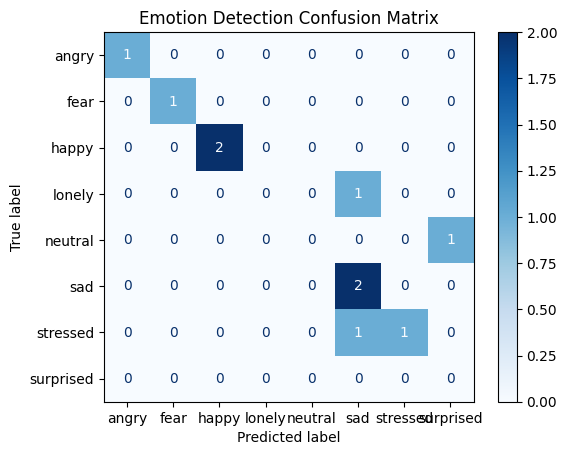

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = [r['expected_emotion'] for r in results]
y_pred = [r['emotion'] for r in results]

labels = sorted(list(set(y_true + y_pred)))

cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')

plt.title("Emotion Detection Confusion Matrix")
plt.show()

In [22]:
# In Colab:
!zip -r empathetic_blenderbot.zip empathetic_blenderbot/
# Download the zip

  adding: empathetic_blenderbot/ (stored 0%)
  adding: empathetic_blenderbot/generation_config.json (deflated 49%)
  adding: empathetic_blenderbot/training_args.bin (deflated 53%)
  adding: empathetic_blenderbot/added_tokens.json (deflated 26%)
  adding: empathetic_blenderbot/special_tokens_map.json (deflated 84%)
  adding: empathetic_blenderbot/model.safetensors (deflated 7%)
  adding: empathetic_blenderbot/merges.txt (deflated 56%)
  adding: empathetic_blenderbot/config.json (deflated 62%)
  adding: empathetic_blenderbot/vocab.json (deflated 68%)
  adding: empathetic_blenderbot/tokenizer_config.json (deflated 80%)


In [23]:
!zip -r blenderbot_results.zip blenderbot_results/

  adding: blenderbot_results/ (stored 0%)
  adding: blenderbot_results/checkpoint-250/ (stored 0%)
  adding: blenderbot_results/checkpoint-250/optimizer.pt (deflated 10%)
  adding: blenderbot_results/checkpoint-250/generation_config.json (deflated 49%)
  adding: blenderbot_results/checkpoint-250/training_args.bin (deflated 53%)
  adding: blenderbot_results/checkpoint-250/trainer_state.json (deflated 61%)
  adding: blenderbot_results/checkpoint-250/model.safetensors (deflated 7%)
  adding: blenderbot_results/checkpoint-250/config.json (deflated 62%)
  adding: blenderbot_results/checkpoint-250/scheduler.pt (deflated 61%)
  adding: blenderbot_results/checkpoint-250/rng_state.pth (deflated 26%)
  adding: blenderbot_results/checkpoint-1000/ (stored 0%)
  adding: blenderbot_results/checkpoint-1000/optimizer.pt (deflated 10%)
  adding: blenderbot_results/checkpoint-1000/generation_config.json (deflated 49%)
  adding: blenderbot_results/checkpoint-1000/training_args.bin (deflated 53%)
  adding